<a href="https://colab.research.google.com/github/Agwora/Agwora/blob/main/Returncalculation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#here we used /content/sample_data/Kenya 20-Year Bond Yield Historical Data (1).csv and
#/content/sample_data/SP500.csv data to calculate the returns for the close prices
#we will late use our old code the fit the model for the parameter estimations
#after parameter estimation we will forecast the returns for as per the old code
#then later compare the results

#the big concerns here is to know the datas we used, what are we suppost to compares in out datas
#and what to conclude

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#loading the time series data
Data1=pd.read_csv("/content/sample_data/SP500.csv",index_col=0,
parse_dates=True)
Data1

,SP500
Date,
2016-02-29,1932.23
2016-03-01,1978.35
2016-03-02,1986.45
2016-03-03,1993.40
2016-03-04,1999.99
...,...
2025-12-26,6929.94
2025-12-29,6905.74
2025-12-30,6896.24


In [ ]:
Data2=pd.read_csv("/content/sample_data/Kenya 20-Year Bond Yield Historical Data (1).csv",
index_col=0,parse_dates=True)
Data2

,Price,Open,High,Low,Change %
Date,,,,,
2026-01-01,13.350,13.350,13.350,13.350,0.00%
2025-12-31,13.350,13.350,13.350,13.350,0.48%
2025-12-30,13.286,13.350,13.350,13.286,0.00%
2025-12-29,13.286,13.286,13.286,13.286,-0.48%
2025-12-26,13.350,13.350,13.350,13.350,0.00%
...,...,...,...,...,...
2008-07-10,14.890,14.890,14.890,14.890,0.00%
2008-07-09,14.890,14.890,14.890,14.890,0.00%
2008-07-08,14.890,14.890,14.890,14.890,-0.01%


In [ ]:
#merging the two data into one
new_data=pd.merge(Data1,Data2,how='inner',left_index=True,right_index=True)
new_data

,SP500,Price,Open,High,Low,Change %
Date,,,,,,
2016-02-29,1932.23,15.000,15.000,15.000,15.000,0.00%
2016-03-01,1978.35,15.000,15.000,15.000,15.000,0.00%
2016-03-02,1986.45,15.000,15.000,15.000,15.000,0.00%
2016-03-03,1993.40,14.500,14.500,14.500,14.500,-3.33%
2016-03-04,1999.99,14.500,14.500,14.500,14.500,0.00%
...,...,...,...,...,...,...
2025-12-26,6929.94,13.350,13.350,13.350,13.350,0.00%
2025-12-29,6905.74,13.286,13.286,13.286,13.286,-0.48%
2025-12-30,6896.24,13.286,13.350,13.350,13.286,0.00%


In [ ]:
#renaming the Price and SP500 columns
new_data.rename(columns={'Price':'KenyaPrice_close'},inplace=True)
new_data.rename(columns={'SP500':'SP500Price_close'},inplace=True)
new_data

,SP500Price_close,KenyaPrice_close,Open,High,Low,Change %
Date,,,,,,
2016-02-29,1932.23,15.000,15.000,15.000,15.000,0.00%
2016-03-01,1978.35,15.000,15.000,15.000,15.000,0.00%
2016-03-02,1986.45,15.000,15.000,15.000,15.000,0.00%
2016-03-03,1993.40,14.500,14.500,14.500,14.500,-3.33%
2016-03-04,1999.99,14.500,14.500,14.500,14.500,0.00%
...,...,...,...,...,...,...
2025-12-26,6929.94,13.350,13.350,13.350,13.350,0.00%
2025-12-29,6905.74,13.286,13.286,13.286,13.286,-0.48%
2025-12-30,6896.24,13.286,13.350,13.350,13.286,0.00%


In [ ]:
#slicing the data and remaining with the 2 closing prices alone for return calculations
new_data1=new_data[['KenyaPrice_close','SP500Price_close']]
new_data1

,KenyaPrice_close,SP500Price_close
Date,,
2016-02-29,15.000,1932.23
2016-03-01,15.000,1978.35
2016-03-02,15.000,1986.45
2016-03-03,14.500,1993.40
2016-03-04,14.500,1999.99
...,...,...
2025-12-26,13.350,6929.94
2025-12-29,13.286,6905.74
2025-12-30,13.286,6896.24


In [ ]:
#checking for the missing values
new_data1.isnull().sum()

,0
KenyaPrice_close,0
SP500Price_close,89


In [ ]:
new_data1.ffill(inplace=True)

/tmp/ipykernel_534/2840343336.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data1.ffill(inplace=True)


In [ ]:
new_data1.isna().sum() #filling out the na cells

,0
KenyaPrice_close,0
SP500Price_close,0


In [ ]:
#calculating daily log returns

new_data1["SP500Log_returns"]=np.log(new_data1["SP500Price_close"]/new_data1["SP500Price_close"].shift(1))
# For Kenya bond
new_data1["Kenyan_returns"] = new_data1["KenyaPrice_close"].diff().dropna()



/tmp/ipykernel_534/491044357.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data1["SP500Log_returns"]=np.log(new_data1["SP500Price_close"]/new_data1["SP500Price_close"].shift(1))
/tmp/ipykernel_534/491044357.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data1["Kenyan_returns"] = new_data1["KenyaPrice_close"].diff().dropna()


In [ ]:
new_data1

,KenyaPrice_close,SP500Price_close,SP500Log_returns,Kenyan_returns
Date,,,,
2016-02-29,15.000,1932.23,NaN,NaN
2016-03-01,15.000,1978.35,0.023588,0.000
2016-03-02,15.000,1986.45,0.004086,0.000
2016-03-03,14.500,1993.40,0.003493,-0.500
2016-03-04,14.500,1999.99,0.003300,0.000
...,...,...,...,...
2025-12-26,13.350,6929.94,-0.000304,0.000
2025-12-29,13.286,6905.74,-0.003498,-0.064
2025-12-30,13.286,6896.24,-0.001377,0.000


In [ ]:
#droing the na row
new_data1.dropna(inplace=True)
new_data1

/tmp/ipykernel_534/3413513367.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data1.dropna(inplace=True)


,KenyaPrice_close,SP500Price_close,SP500Log_returns,Kenyan_returns
Date,,,,
2016-03-01,15.000,1978.35,0.023588,0.000
2016-03-02,15.000,1986.45,0.004086,0.000
2016-03-03,14.500,1993.40,0.003493,-0.500
2016-03-04,14.500,1999.99,0.003300,0.000
2016-03-07,14.500,2001.76,0.000885,0.000
...,...,...,...,...
2025-12-26,13.350,6929.94,-0.000304,0.000
2025-12-29,13.286,6905.74,-0.003498,-0.064
2025-12-30,13.286,6896.24,-0.001377,0.000


In [ ]:

print("Descriptive Statistics:")
print(new_data1.describe())
print("\nSkewness:")
print(new_data1.skew())
print("\nKurtosis:")
print(new_data1.kurt())

Descriptive Statistics:
       KenyaPrice_close  SP500Price_close  SP500Log_returns  Kenyan_returns
count       2551.000000       2551.000000       2551.000000     2551.000000
mean          14.121734       3794.435147          0.000496       -0.000647
std            1.832317       1277.356279          0.011207        1.997716
min           12.250000       1978.350000         -0.127652      -71.271000
25%           13.250000       2727.740000         -0.003300        0.000000
50%           13.670000       3719.040000          0.000493        0.000000
75%           14.700000       4519.830000          0.005583        0.000000
max           85.521000       6932.050000          0.090895       70.818000

Skewness:
KenyaPrice_close    23.480088
SP500Price_close     0.597788
SP500Log_returns    -0.704950
Kenyan_returns      -0.336436
dtype: float64

Kurtosis:
KenyaPrice_close     903.769475
SP500Price_close      -0.586105
SP500Log_returns      17.926978
Kenyan_returns      1254.544930
dtype: 

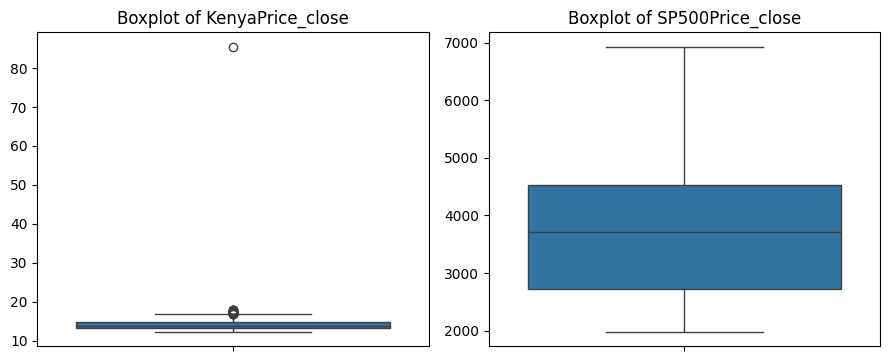

In [ ]:
# Drawing boxplots for the data
plt.figure(figsize=(9, 7))
for i, column in enumerate(new_data1.columns[:2]):
    plt.subplot(2, 2, i + 1)  # Adjust subplot grid as needed based on number of columns
    sns.boxplot(y=new_data1[column])
    plt.title(f'Boxplot of {column}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
new_data1

,KenyaPrice_close,SP500Price_close,SP500Log_returns,Kenyan_returns
Date,,,,
2016-03-01,15.000,1978.35,0.023588,0.000
2016-03-02,15.000,1986.45,0.004086,0.000
2016-03-03,14.500,1993.40,0.003493,-0.500
2016-03-04,14.500,1999.99,0.003300,0.000
2016-03-07,14.500,2001.76,0.000885,0.000
...,...,...,...,...
2025-12-26,13.350,6929.94,-0.000304,0.000
2025-12-29,13.286,6905.74,-0.003498,-0.064
2025-12-30,13.286,6896.24,-0.001377,0.000


In [ ]:
new_data1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2551 entries, 2016-03-01 to 2026-01-01
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   KenyaPrice_close  2551 non-null   float64
 1   SP500Price_close  2551 non-null   float64
 2   SP500Log_returns  2551 non-null   float64
 3   Kenyan_returns    2551 non-null   float64
dtypes: float64(4)
memory usage: 99.6 KB


In [ ]:
#saving the csv file
new_data1.to_csv("Returns_Data1.csv",index=False)